In [2]:
from google.colab import files
files.upload()

Saving Rainfall.csv to Rainfall.csv


{'Rainfall.csv': b'day,pressure ,maxtemp,temparature,mintemp,dewpoint,humidity ,cloud ,rainfall,sunshine,         winddirection,windspeed\r\n1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80,26.3\r\n2,1022,21.7,18.9,17.2,15.6,81,83,yes,0.6,50,15.3\r\n3,1019.7,20.3,19.3,18,18.4,95,91,yes,0,40,14.2\r\n4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1,50,16.9\r\n5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0,40,13.7\r\n6,1018.8,24.3,20.9,19.2,18,84,51,yes,7.7,20,14.5\r\n7,1021.8,21.4,18.8,17,15,79,56,no,3.4,30,21.5\r\n8,1020.8,21,18.4,16.5,14.4,78,28,no,7.7,60,14.3\r\n9,1020.6,18.9,18.1,17.1,14.3,78,79,no,3.3,70,39.3\r\n10,1017.5,18.5,18,17.2,15.5,85,91,yes,0,70,37.7\r\n11,1016.5,20.4,18.1,16.5,16.4,90,90,yes,2.1,40,23.3\r\n12,1019.9,18.5,17.3,16.1,13.7,79,86,no,0.6,20,23.9\r\n13,1020.8,18.7,16.1,14.2,12.1,77,34,no,9.1,30,24.4\r\n14,1019.3,17.5,16.5,15.6,12.9,79,81,yes,1.5,60,33.2\r\n15,1015.4,16.1,15.1,14.5,14.6,97,97,yes,0,50,37.5\r\n16,1013.5,17.1,16.4,15.5,15.6,95,93,yes,0,60,40\r\n17,1011.5,20.6,17.8,1

In [3]:
# importing our dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

In [4]:
df = pd.read_csv("Rainfall.csv")

In [5]:
df.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [7]:
df.shape

(366, 12)

In [8]:
df["day"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [9]:
# stripping empty spaces
df.columns = df.columns.str.strip()

In [10]:
# drop the column day
df.drop(columns=["day"], inplace=True)

In [11]:
df.columns

Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed'],
      dtype='object')

In [12]:
# check for missing values
df.isna().sum()

,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
rainfall,0
sunshine,0
winddirection,1


In [13]:
df["winddirection"].unique()

array([ 80.,  50.,  40.,  20.,  30.,  60.,  70.,  10., 200., 220., 120.,
       190., 210., 300., 240., 180., 230.,  90., 170., 150., 100., 130.,
        nan, 160., 270., 280., 250., 260., 290., 350., 110., 140.])

In [14]:
df["winddirection"].fillna(df["winddirection"].mode()[0], inplace=True)
df["windspeed"].fillna(df["windspeed"].median(), inplace=True)

/tmp/ipython-input-4094922657.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["winddirection"].fillna(df["winddirection"].mode()[0], inplace=True)
/tmp/ipython-input-4094922657.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

In [15]:
df.isna().sum()

,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
rainfall,0
sunshine,0
winddirection,0


In [16]:
df.dtypes

,0
pressure,float64
maxtemp,float64
temparature,float64
mintemp,float64
dewpoint,float64
humidity,int64
cloud,int64
rainfall,object
sunshine,float64
winddirection,float64


In [17]:
df["rainfall"].unique()

array(['yes', 'no'], dtype=object)

In [18]:
df["rainfall"] = df["rainfall"].map({"yes": 1,"no": 0 })

In [19]:
df.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,1,0.0,40.0,13.7


EDA

In [20]:
# statistical analysis
df.describe()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,1013.742623,26.191257,23.747268,21.894536,19.989071,80.177596,71.128415,0.680328,4.419399,101.284153,21.534153
std,6.414776,5.978343,5.632813,5.594153,5.997021,10.062470,21.798012,0.466988,3.934398,81.722827,10.056054
min,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,0.000000,10.000000,4.400000
25%,1008.500000,21.200000,18.825000,17.125000,16.125000,75.000000,58.000000,0.000000,0.500000,40.000000,13.725000
50%,1013.000000,27.750000,25.450000,23.700000,21.950000,80.500000,80.000000,1.000000,3.500000,70.000000,20.500000
75%,1018.100000,31.200000,28.600000,26.575000,25.000000,87.000000,88.000000,1.000000,8.200000,190.000000,27.825000
max,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,1.000000,12.100000,350.000000,59.500000


In [21]:
df.columns

Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed'],
      dtype='object')

In [22]:
#setting style for our plot(seaborn)
sns.set(style = "whitegrid")

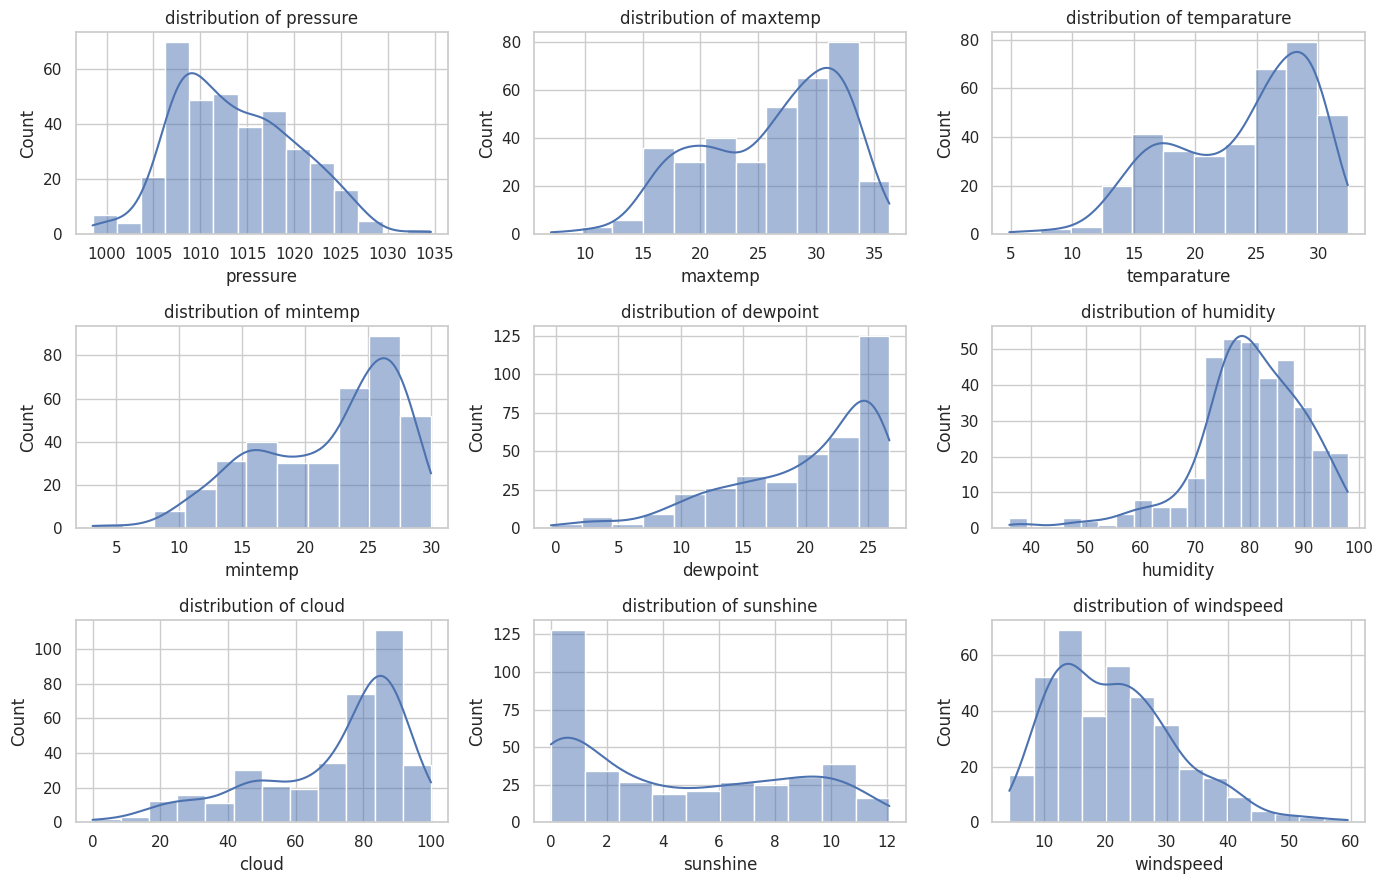

In [23]:
plt.figure(figsize=(14,9))

for i, column in enumerate(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud','sunshine', 'windspeed'], 1):
  plt.subplot(3, 3, i)
  sns.histplot(df[column], kde=True)
  plt.title(f"distribution of {column}")

plt.tight_layout()
plt.show()

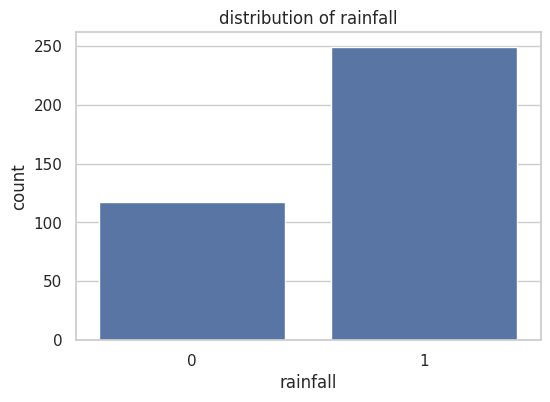

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x="rainfall", data=df)
plt.title("distribution of rainfall")
plt.show()

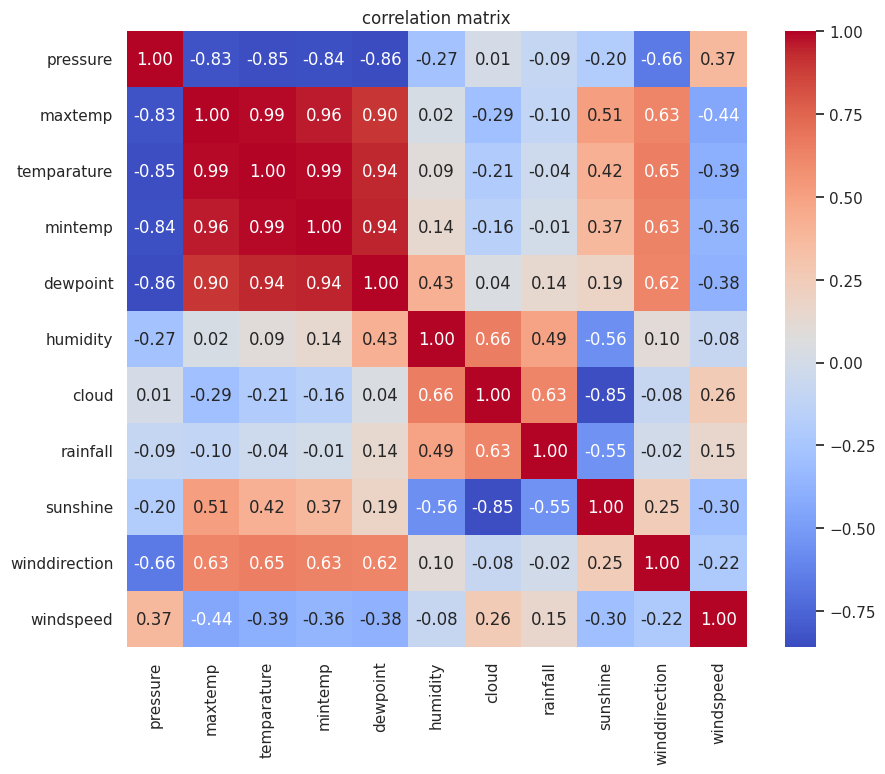

In [25]:
# correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("correlation matrix")
plt.show()

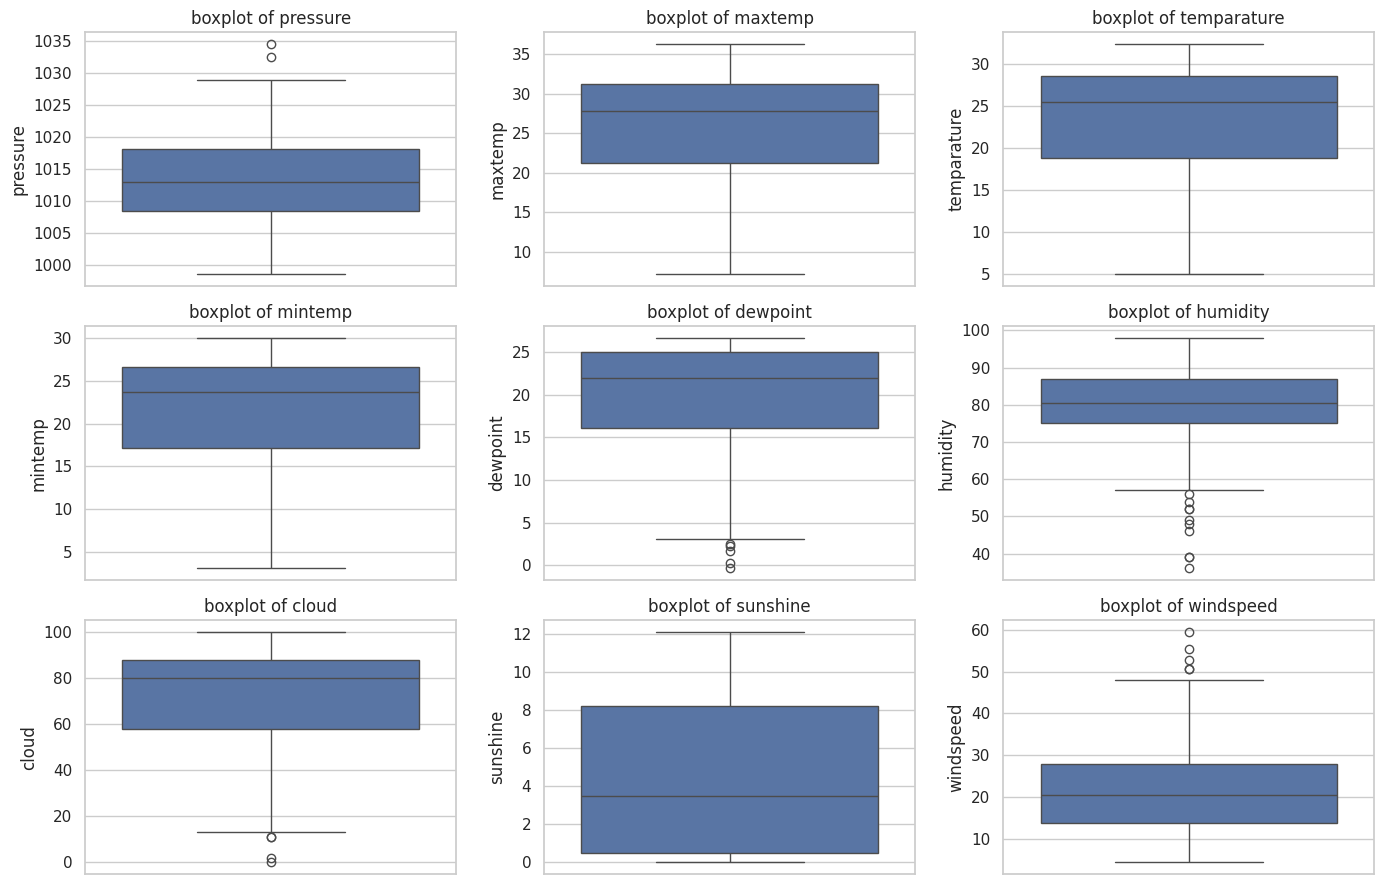

In [26]:
plt.figure(figsize=(14,9))

for i, column in enumerate(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud','sunshine', 'windspeed'], 1):
  plt.subplot(3, 3, i)
  sns.boxplot(df[column])
  plt.title(f"boxplot of {column}")

plt.tight_layout()
plt.show()

you can either replace this outliers by median, median isnt affected bu=y ouliers unlike mean

In [27]:
# drop highly corelated columns
df = df.drop(columns=['maxtemp', 'temparature', 'mintemp'])


In [28]:
df.head()


,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,19.9,95,81,1,0.0,40.0,13.7


In [29]:
df["rainfall"].value_counts()

,count
rainfall,
1,249
0,117


In [30]:
# seperate majority class with minority
df_major = df[df["rainfall"] == 1]

df_minor = df[df["rainfall"] == 0]

print(df_major.shape)
print(df_minor.shape)

(249, 8)
(117, 8)


In [31]:

df_major_downsampled = resample(df_major, replace=False, n_samples=len(df_minor), random_state=42)

In [32]:
df_major_downsampled.shape

(117, 8)

In [33]:
df_downsampled = pd.concat([df_major_downsampled, df_minor])

In [34]:
df_downsampled.shape

(234, 8)

In [35]:
df_downsampled.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
188,1005.9,25.6,77,53,1,10.5,270.0,11.3
9,1017.5,15.5,85,91,1,0.0,70.0,37.7
137,1012.3,20.1,80,86,1,0.3,80.0,39.5
89,1018.3,16.3,79,89,1,2.4,40.0,14.8
157,1008.8,24.7,91,80,1,2.2,20.0,11.2


In [36]:
df_downsampled = df_downsampled.sample(frac=1, random_state=42).reset_index(drop=True)

In [37]:
df_downsampled.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1022.2,14.1,78,90,1,0.0,30.0,28.5
1,1013.4,19.5,69,17,0,10.5,70.0,12.4
2,1006.1,24.4,74,27,0,10.8,220.0,8.7
3,1007.6,24.8,85,84,1,1.8,70.0,34.8
4,1021.2,8.4,66,18,0,10.1,20.0,24.4


splitting our data

In [38]:
x = df_downsampled.drop(columns=["rainfall"])
y = df_downsampled["rainfall"]

In [39]:
print(x.shape)
print(y.shape)

(234, 7)
(234,)


In [40]:
# split train and test data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42 )

In [41]:
rf_model = RandomForestClassifier(random_state=42)

param_grid_rf = {
    "n_estimators":[50,100,200],
    "max_features":["sqrt","log"],
    "max_depth":[None, 10, 20, 30],
    "min_samples_split":[2, 5, 10],
    "min_samples_leaf":[1,2,4]

}

In [42]:
df_model = DecisionTreeClassifier(random_state=42)

param_grid_df = {
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [43]:
kn_model = KNeighborsClassifier()

param_grid_kn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [44]:
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf,cv=5, n_jobs=-1, verbose=2 )
grid_search_rf.fit(x_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
540 fits failed out of a total of 1080.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
540 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/uti

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

In [45]:
grid_search_df = GridSearchCV(estimator=df_model, param_grid=param_grid_df,cv=5, n_jobs=-1, verbose=2 )
grid_search_df.fit(x_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             verbose=2)

In [46]:
grid_search_kn = GridSearchCV(estimator=kn_model, param_grid=param_grid_kn,cv=5, n_jobs=-1, verbose=2 )
grid_search_kn.fit(x_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9, 11],
                         'weights': ['uniform', 'distance']},
             verbose=2)

In [47]:
best_rf_model = grid_search_rf.best_estimator_

print("best parameters for Random Forest:", grid_search_rf.best_params_)

best_df_model = grid_search_df.best_estimator_

print("best parameters for Decisontresclassifier:", grid_search_df.best_params_)

best_kn_model = grid_search_kn.best_estimator_

print("best parameters for KNeigborsclassifier:", grid_search_kn.best_params_)

best parameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}
best parameters for Decisontresclassifier: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
best parameters for KNeigborsclassifier: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}


In [48]:
# model evaluation for randomforest
cv_scores_rf = cross_val_score(best_rf_model, x_train, y_train, cv=5)
print("Cross-validation scores:", cv_scores_rf)
print("Mean cross-validation score:", np.mean(cv_scores_rf))
# model evaluation for decisontress
cv_scores_df = cross_val_score(best_df_model, x_train, y_train, cv=5)
print("Cross-validation scores:", cv_scores_df)
print("Mean cross-validation score:", np.mean(cv_scores_df))
#model evaluation for kneigbor
cv_scores_kn = cross_val_score(best_kn_model, x_train, y_train, cv=5)
print("Cross-validation scores:", cv_scores_kn)
print("Mean cross-validation score:", np.mean(cv_scores_kn))

Cross-validation scores: [0.68421053 0.81578947 0.83783784 0.83783784 0.91891892]
Mean cross-validation score: 0.818918918918919
Cross-validation scores: [0.71052632 0.71052632 0.89189189 0.75675676 0.81081081]
Mean cross-validation score: 0.7761024182076814
Cross-validation scores: [0.76315789 0.78947368 0.83783784 0.78378378 0.89189189]
Mean cross-validation score: 0.8132290184921764


/tmp/ipython-input-385152074.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Mean CV Score', data=performance_df, palette='viridis')


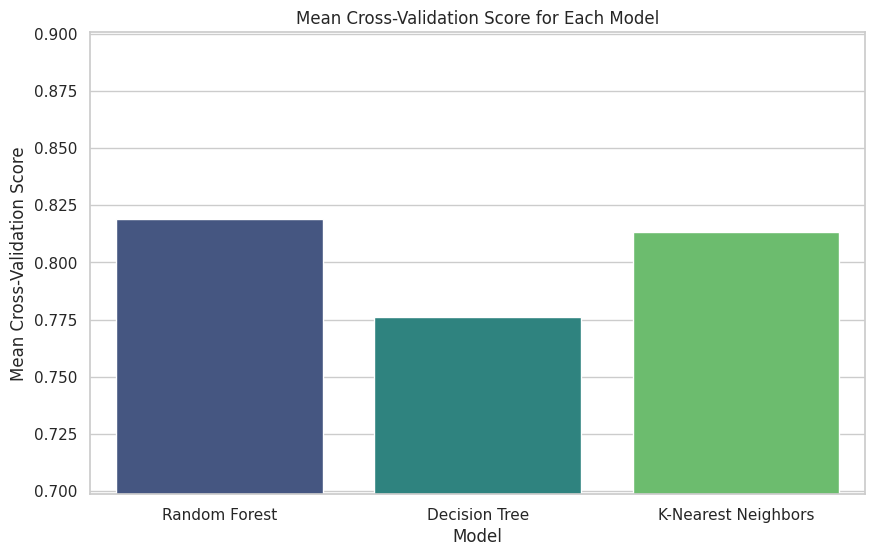

In [49]:
model_names = ['Random Forest', 'Decision Tree', 'K-Nearest Neighbors']
mean_cv_scores = [
    np.mean(cv_scores_rf),
    np.mean(cv_scores_df),
    np.mean(cv_scores_kn)
]

performance_df = pd.DataFrame({
    'Model': model_names,
    'Mean CV Score': mean_cv_scores
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Mean CV Score', data=performance_df, palette='viridis')
plt.title('Mean Cross-Validation Score for Each Model')
plt.xlabel('Model')
plt.ylabel('Mean Cross-Validation Score')
plt.ylim(min(mean_cv_scores) * 0.9, max(mean_cv_scores) * 1.1) # Adjust y-axis limit for better visualization
plt.show()

barchart shows randomforest as the best performing model

In [50]:
y_pred = best_rf_model.predict(x_test)
accuracy_score = accuracy_score(y_test, y_pred)



In [51]:
confusion_matrix = confusion_matrix(y_pred, y_test)
classification_report = classification_report(y_pred, y_test)

In [52]:
print("accuracy score:", accuracy_score)

accuracy score: 0.7446808510638298


In [53]:
print("classification report:", classification_report)
print("confusion matrix:", confusion_matrix)

classification report:               precision    recall  f1-score   support

           0       0.71      0.77      0.74        22
           1       0.78      0.72      0.75        25

    accuracy                           0.74        47
   macro avg       0.75      0.75      0.74        47
weighted avg       0.75      0.74      0.74        47

confusion matrix: [[17  5]
 [ 7 18]]


In [54]:
df_downsampled.columns

Index(['pressure', 'dewpoint', 'humidity', 'cloud', 'rainfall', 'sunshine',
       'winddirection', 'windspeed'],
      dtype='object')

In [55]:
input_data = (1022.2, 14.1, 78, 90, 0.0, 30.0, 28.5)

input_df = pd.DataFrame([input_data], columns=['pressure', 'dewpoint', 'humidity', 'cloud','sunshine',
       'winddirection', 'windspeed'])

predictions = best_rf_model.predict(input_df)

if predictions == 1:
  print("theres is a rainfall")
else:
    print("no rainfall")

theres is a rainfall


LOAD AND SAVE THE MODEL

In [56]:
import pickle


In [58]:
import pickle

# Save the best Random Forest model
with open('rainfall_prediction_model.pkl', 'wb') as file:
    pickle.dump(best_rf_model, file)

In [61]:
files.download("rainfall_prediction_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
input_data = (1013.4,19.5,69,17,10.5,70.0,12.4)

input_df = pd.DataFrame([input_data], columns=['pressure', 'dewpoint', 'humidity', 'cloud','sunshine',
       'winddirection', 'windspeed'])

predictions = best_rf_model.predict(input_df)

if predictions == 1:
  print("theres is a rainfall")
else:
    print("no rainfall")

no rainfall
